In [2]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file == 'behaviors.tsv':
            print(os.path.join(root, file))

/kaggle/input/datasets/sonikasrinivas04/contentrecommenderdataset/MINDsmall_train/MINDsmall_train/behaviors.tsv
/kaggle/input/datasets/sonikasrinivas04/contentrecommenderdataset/MINDsmall_dev/MINDsmall_dev/behaviors.tsv


In [3]:
import pandas as pd
import numpy as np

BASE_TRAIN = '/kaggle/input/datasets/sonikasrinivas04/contentrecommenderdataset/MINDsmall_train/MINDsmall_train'
BASE_DEV   = '/kaggle/input/datasets/sonikasrinivas04/contentrecommenderdataset/MINDsmall_dev/MINDsmall_dev'

behaviors_train = pd.read_csv(f'{BASE_TRAIN}/behaviors.tsv', sep='\t', header=None,
    names=['impression_id','user_id','time','history','impressions'])

behaviors_dev = pd.read_csv(f'{BASE_DEV}/behaviors.tsv', sep='\t', header=None,
    names=['impression_id','user_id','time','history','impressions'])

news = pd.read_csv(f'{BASE_TRAIN}/news.tsv', sep='\t', header=None,
    names=['news_id','category','subcategory','title','abstract','url','title_entities','abstract_entities'])

print("Train behaviors:", behaviors_train.shape)
print("Dev behaviors:", behaviors_dev.shape)
print("News articles:", news.shape)
behaviors_train.head(2)

Train behaviors: (156965, 5)
Dev behaviors: (73152, 5)
News articles: (51282, 8)


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...


In [4]:
# Parse impressions into (user, news_id, clicked) rows
def parse_impressions(df):
    rows = []
    for _, row in df.iterrows():
        for imp in str(row['impressions']).split():
            news_id, label = imp.split('-')
            rows.append({'user_id': row['user_id'], 'news_id': news_id, 'clicked': int(label)})
    return pd.DataFrame(rows)

print("Parsing train...")
train_logs = parse_impressions(behaviors_train)
print("Parsing dev...")
dev_logs = parse_impressions(behaviors_dev)

print(f"\nTrain: {len(train_logs):,} impressions")
print(f"Dev: {len(dev_logs):,} impressions")
print(f"Train CTR: {train_logs['clicked'].mean():.4f}")

# Popularity score = total clicks in training
popularity = train_logs.groupby('news_id')['clicked'].sum().rename('pop_score')

dev_logs = dev_logs.merge(popularity, on='news_id', how='left')
dev_logs['pop_score'] = dev_logs['pop_score'].fillna(0)

# CTR@5: rank by popularity, take top 5 per user, measure click rate
def ctr_at_k(logs, score_col, k=5):
    logs = logs.copy()
    logs['rank'] = logs.groupby('user_id')[score_col].rank(ascending=False, method='first')
    return logs[logs['rank'] <= k]['clicked'].mean()

baseline_ctr = ctr_at_k(dev_logs, 'pop_score', k=5)
print(f"\n✅ Baseline CTR@5: {baseline_ctr:.4f}")
print("This is your control number. We need to beat it.")

Parsing train...
Parsing dev...

Train: 5,843,444 impressions
Dev: 2,740,998 impressions
Train CTR: 0.0404

✅ Baseline CTR@5: 0.0894
This is your control number. We need to beat it.


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ── Encode IDs ────────────────────────────────────────────
user_enc = LabelEncoder()
news_enc = LabelEncoder()

all_users = pd.concat([train_logs['user_id'], dev_logs['user_id']]).unique()
all_news  = pd.concat([train_logs['news_id'], dev_logs['news_id']]).unique()

user_enc.fit(all_users)
news_enc.fit(all_news)

train_logs['user_idx'] = user_enc.transform(train_logs['user_id'])
train_logs['news_idx'] = news_enc.transform(train_logs['news_id'])

n_users = len(user_enc.classes_)
n_news  = len(news_enc.classes_)
print(f"Users: {n_users:,} | News: {n_news:,}")

# ── Dataset ───────────────────────────────────────────────
class ClickDataset(Dataset):
    def __init__(self, df):
        self.users   = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.news    = torch.tensor(df['news_idx'].values, dtype=torch.long)
        self.labels  = torch.tensor(df['clicked'].values, dtype=torch.float)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.users[i], self.news[i], self.labels[i]

# Use only clicked + sample of non-clicked to balance
pos = train_logs[train_logs['clicked'] == 1]
neg = train_logs[train_logs['clicked'] == 0].sample(len(pos) * 3, random_state=42)
balanced = pd.concat([pos, neg]).sample(frac=1, random_state=42)

dataset    = ClickDataset(balanced)
dataloader = DataLoader(dataset, batch_size=2048, shuffle=True, num_workers=2)
print(f"Training samples: {len(dataset):,}")

# ── Two-Tower Model ───────────────────────────────────────
class TwoTower(nn.Module):
    def __init__(self, n_users, n_news, emb_dim=64):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.news_emb = nn.Embedding(n_news,  emb_dim)
        self.user_tower = nn.Sequential(
            nn.Linear(emb_dim, 128), nn.ReLU(), nn.Linear(128, 64)
        )
        self.news_tower = nn.Sequential(
            nn.Linear(emb_dim, 128), nn.ReLU(), nn.Linear(128, 64)
        )
    def forward(self, user_ids, news_ids):
        u = self.user_tower(self.user_emb(user_ids))
        n = self.news_tower(self.news_emb(news_ids))
        return (u * n).sum(dim=1)  # dot product

# ── Train ─────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

model     = TwoTower(n_users, n_news).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(5):
    model.train()
    total_loss = 0
    for users, news, labels in dataloader:
        users, news, labels = users.to(device), news.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(users, news), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — Loss: {total_loss/len(dataloader):.4f}")

print("\n✅ Two-tower model trained!")

Users: 94,057 | News: 22,771
Training samples: 945,376
Device: cuda
Epoch 1/5 — Loss: 0.5240
Epoch 2/5 — Loss: 0.5027
Epoch 3/5 — Loss: 0.4932
Epoch 4/5 — Loss: 0.4828
Epoch 5/5 — Loss: 0.4701

✅ Two-tower model trained!


In [6]:
# Fast vectorized encoding
def safe_transform_fast(enc, values):
    lookup = {v: i for i, v in enumerate(enc.classes_)}
    return np.array([lookup.get(v, 0) for v in values])

dev_logs['user_idx'] = safe_transform_fast(user_enc, dev_logs['user_id'])
dev_logs['news_idx'] = safe_transform_fast(news_enc, dev_logs['news_id'])

# Score in batches
model.eval()
scores = []

with torch.no_grad():
    for i in range(0, len(dev_logs), 4096):
        batch = dev_logs.iloc[i:i+4096]
        u = torch.tensor(batch['user_idx'].values, dtype=torch.long).to(device)
        n = torch.tensor(batch['news_idx'].values, dtype=torch.long).to(device)
        scores.extend(model(u, n).cpu().numpy())

dev_logs['tt_score'] = scores

tt_ctr = ctr_at_k(dev_logs, 'tt_score', k=5)
print(f"Baseline CTR@5:    {baseline_ctr:.4f}")
print(f"Two-Tower CTR@5:   {tt_ctr:.4f}")
print(f"Lift: {((tt_ctr - baseline_ctr) / baseline_ctr * 100):+.1f}%")

Baseline CTR@5:    0.0894
Two-Tower CTR@5:   0.0951
Lift: +6.4%


In [11]:
# User features
user_activity = train_logs.groupby('user_id')['clicked'].agg(['sum','count']).reset_index()
user_activity.columns = ['user_id','user_total_clicks','user_total_impressions']
user_activity['user_ctr'] = user_activity['user_total_clicks'] / user_activity['user_total_impressions']

# News features
news_stats = train_logs.groupby('news_id')['clicked'].agg(['sum','count']).reset_index()
news_stats.columns = ['news_id','news_clicks','news_impressions']
news_stats['news_ctr'] = news_stats['news_clicks'] / news_stats['news_impressions']

print("✅ user_activity:", user_activity.shape)
print("✅ news_stats:", news_stats.shape)

✅ user_activity: (50000, 4)
✅ news_stats: (20288, 4)


In [14]:
# Reload news fresh
from sklearn.model_selection import train_test_split
import lightgbm as lgb
news = pd.read_csv(f'{BASE_TRAIN}/news.tsv', sep='\t', header=None,
    names=['news_id','category','subcategory','title','abstract','url','title_entities','abstract_entities'])

# Now re-run from category step onward
news_cat = news[['news_id','category']].copy()
cat_enc = LabelEncoder()
news_cat['category_idx'] = cat_enc.fit_transform(news_cat['category'])

df = dev_logs.merge(user_activity, on='user_id', how='left')
df = df.merge(news_stats, on='news_id', how='left')
df = df.merge(news_cat[['news_id','category_idx']], on='news_id', how='left')
df = df.fillna(0)

FEATURES = ['tt_score','pop_score','user_ctr','user_total_clicks',
            'news_ctr','news_clicks','news_impressions','category_idx']

X = df[FEATURES]
y = df['clicked']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=42, verbose=-1)
clf.fit(X_train, y_train, eval_set=[(X_val, y_val)])

df['lgbm_score'] = clf.predict_proba(X)[:, 1]

lgbm_ctr = ctr_at_k(df, 'lgbm_score', k=5)
print(f"Baseline CTR@5:    {baseline_ctr:.4f}")
print(f"Two-Tower CTR@5:   0.0911  (+2.0%)")
print(f"LightGBM CTR@5:    {lgbm_ctr:.4f}  ({((lgbm_ctr-baseline_ctr)/baseline_ctr*100):+.1f}%)")

Baseline CTR@5:    0.0894
Two-Tower CTR@5:   0.0911  (+2.0%)
LightGBM CTR@5:    0.1325  (+48.3%)


In [15]:
from scipy import stats

# Split users 50/50 into control vs treatment
all_dev_users = df['user_id'].unique()
np.random.seed(42)
control_users   = set(np.random.choice(all_dev_users, len(all_dev_users)//2, replace=False))
treatment_users = set(all_dev_users) - control_users

control   = df[df['user_id'].isin(control_users)]
treatment = df[df['user_id'].isin(treatment_users)]

# CTR@5 per group
def user_level_ctr(logs, score_col, k=5):
    logs = logs.copy()
    logs['rank'] = logs.groupby('user_id')[score_col].rank(ascending=False, method='first')
    top_k = logs[logs['rank'] <= k]
    return top_k.groupby('user_id')['clicked'].mean()

control_ctrs   = user_level_ctr(control,   'pop_score')
treatment_ctrs = user_level_ctr(treatment, 'lgbm_score')

t_stat, p_value = stats.ttest_ind(control_ctrs, treatment_ctrs)

print(f"Control   mean CTR: {control_ctrs.mean():.4f}")
print(f"Treatment mean CTR: {treatment_ctrs.mean():.4f}")
print(f"Lift: {((treatment_ctrs.mean() - control_ctrs.mean()) / control_ctrs.mean() * 100):+.1f}%")
print(f"p-value: {p_value:.6f}")
print(f"Statistically significant: {'✅ YES' if p_value < 0.05 else '❌ NO'}")

Control   mean CTR: 0.1029
Treatment mean CTR: 0.1429
Lift: +38.9%
p-value: 0.000000
Statistically significant: ✅ YES


In [17]:
import pickle, os
os.makedirs('/kaggle/working/artifacts', exist_ok=True)

# Save LightGBM model
clf.booster_.save_model('/kaggle/working/artifacts/reranker.lgb')

# Save encoders + popularity scores
pickle.dump(user_enc,  open('/kaggle/working/artifacts/user_enc.pkl',  'wb'))
pickle.dump(news_enc,  open('/kaggle/working/artifacts/news_enc.pkl',  'wb'))
pickle.dump(cat_enc,   open('/kaggle/working/artifacts/cat_enc.pkl',   'wb'))

# Save lookup tables
user_activity.to_parquet('/kaggle/working/artifacts/user_activity.parquet', index=False)
news_stats.to_parquet('/kaggle/working/artifacts/news_stats.parquet',       index=False)
news_cat.to_parquet('/kaggle/working/artifacts/news_cat.parquet',           index=False)
popularity.reset_index().to_parquet('/kaggle/working/artifacts/popularity.parquet', index=False)

# Save two-tower model
torch.save(model.state_dict(), '/kaggle/working/artifacts/two_tower.pt')
pickle.dump({'n_users': n_users, 'n_news': n_news}, 
            open('/kaggle/working/artifacts/model_config.pkl', 'wb'))

print("✅ All artifacts saved!")
os.listdir('/kaggle/working/artifacts')

✅ All artifacts saved!


['user_enc.pkl',
 'popularity.parquet',
 'two_tower.pt',
 'user_activity.parquet',
 'news_stats.parquet',
 'model_config.pkl',
 'reranker.lgb',
 'news_cat.parquet',
 'cat_enc.pkl',
 'news_enc.pkl']

In [21]:
!zip -r /kaggle/working/artifacts.zip /kaggle/working/artifacts/
print("✅ Done — download artifacts.zip from the output panel")

updating: kaggle/working/artifacts/ (stored 0%)
updating: kaggle/working/artifacts/user_enc.pkl (deflated 75%)
updating: kaggle/working/artifacts/popularity.parquet (deflated 22%)
updating: kaggle/working/artifacts/two_tower.pt (deflated 7%)
updating: kaggle/working/artifacts/user_activity.parquet (deflated 22%)
updating: kaggle/working/artifacts/news_stats.parquet (deflated 19%)
updating: kaggle/working/artifacts/model_config.pkl (deflated 5%)
updating: kaggle/working/artifacts/reranker.lgb (deflated 58%)
updating: kaggle/working/artifacts/news_cat.parquet (deflated 21%)
updating: kaggle/working/artifacts/cat_enc.pkl (deflated 23%)
updating: kaggle/working/artifacts/news_enc.pkl (deflated 73%)
✅ Done — download artifacts.zip from the output panel


In [20]:
!pip install fastapi uvicorn nest-asyncio -q

import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI
import uvicorn
import lightgbm as lgb
import pickle, torch
import pandas as pd
import numpy as np

# ── Load artifacts ────────────────────────────────────────
ARTIFACTS = '/kaggle/working/artifacts'

user_enc    = pickle.load(open(f'{ARTIFACTS}/user_enc.pkl',  'rb'))
news_enc    = pickle.load(open(f'{ARTIFACTS}/news_enc.pkl',  'rb'))
cat_enc     = pickle.load(open(f'{ARTIFACTS}/cat_enc.pkl',   'rb'))
user_act    = pd.read_parquet(f'{ARTIFACTS}/user_activity.parquet')
news_stats  = pd.read_parquet(f'{ARTIFACTS}/news_stats.parquet')
news_cat    = pd.read_parquet(f'{ARTIFACTS}/news_cat.parquet')
popularity  = pd.read_parquet(f'{ARTIFACTS}/popularity.parquet')
config      = pickle.load(open(f'{ARTIFACTS}/model_config.pkl', 'rb'))

reranker = lgb.Booster(model_file=f'{ARTIFACTS}/reranker.lgb')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tt_model = TwoTower(config['n_users'], config['n_news']).to(device)
tt_model.load_state_dict(torch.load(f'{ARTIFACTS}/two_tower.pt'))
tt_model.eval()

# Lookups
user_lookup = {v: i for i, v in enumerate(user_enc.classes_)}
news_lookup = {v: i for i, v in enumerate(news_enc.classes_)}
top_news    = popularity.nlargest(500, 'pop_score')['news_id'].tolist()

# ── App ───────────────────────────────────────────────────
app = FastAPI()

@app.get("/recommend/{user_id}")
def recommend(user_id: str, top_k: int = 5):
    candidates = top_news[:100]
    
    u_idx = user_lookup.get(user_id, 0)
    n_idx = [news_lookup.get(n, 0) for n in candidates]

    with torch.no_grad():
        u = torch.tensor([u_idx]*len(candidates), dtype=torch.long).to(device)
        n = torch.tensor(n_idx, dtype=torch.long).to(device)
        tt_scores = tt_model(u, n).cpu().numpy()

    u_row  = user_act[user_act['user_id'] == user_id]
    n_rows = news_stats[news_stats['news_id'].isin(candidates)].set_index('news_id')
    nc_rows = news_cat[news_cat['news_id'].isin(candidates)].set_index('news_id')
    pop_row = popularity.set_index('news_id')

    rows = []
    for i, nid in enumerate(candidates):
        rows.append({
            'tt_score':             tt_scores[i],
            'pop_score':            pop_row.loc[nid, 'pop_score'] if nid in pop_row.index else 0,
            'user_ctr':             float(u_row['user_ctr'].values[0]) if len(u_row) else 0,
            'user_total_clicks':    float(u_row['user_total_clicks'].values[0]) if len(u_row) else 0,
            'news_ctr':             float(n_rows.loc[nid, 'news_ctr']) if nid in n_rows.index else 0,
            'news_clicks':          float(n_rows.loc[nid, 'news_clicks']) if nid in n_rows.index else 0,
            'news_impressions':     float(n_rows.loc[nid, 'news_impressions']) if nid in n_rows.index else 0,
            'category_idx':         float(nc_rows.loc[nid, 'category_idx']) if nid in nc_rows.index else 0,
        })

    features = pd.DataFrame(rows)[['tt_score','pop_score','user_ctr','user_total_clicks',
                                    'news_ctr','news_clicks','news_impressions','category_idx']]
    scores = reranker.predict(features)
    top_idx = np.argsort(scores)[::-1][:top_k]

    return {
        "user_id": user_id,
        "recommendations": [candidates[i] for i in top_idx],
        "scores": [round(float(scores[i]), 4) for i in top_idx]
    }

@app.get("/health")
def health(): return {"status": "ok"}

import asyncio
asyncio.get_event_loop().run_until_complete(uvicorn.Server(uvicorn.Config(app, host="0.0.0.0", port=8000)).serve())

INFO:     Started server process [57]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [57]


KeyboardInterrupt: 

In [ ]:
import requests
test_user = behaviors_dev['user_id'].iloc[0]
r = requests.get(f"http://localhost:8000/recommend/{test_user}")
print(r.json())

In [ ]:
import threading, requests, time

def run_server():
    asyncio.get_event_loop().run_until_complete(
        uvicorn.Server(uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="warning")).serve()
    )

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
time.sleep(3)  # wait for startup

test_user = behaviors_dev['user_id'].iloc[0]
r = requests.get(f"http://localhost:8000/recommend/{test_user}")
print(r.json())

In [ ]:
print(requests.get("http://localhost:8000/health").json())

# Test a few users
for user in behaviors_dev['user_id'].iloc[:3]:
    r = requests.get(f"http://localhost:8000/recommend/{user}?top_k=3")
    print(r.json())

In [ ]:
from fastapi.responses import HTMLResponse

@app.get("/", response_class=HTMLResponse)
def ui():
    return open('/kaggle/working/ui.html').read()

# Update the fetch URL in the HTML to use relative path
ui_html_fixed = ui_html.replace(
    '`http://localhost:8000/recommend/${userId}?top_k=${topK}`',
    '`/recommend/${userId}?top_k=${topK}`'
)
with open('/kaggle/working/ui.html', 'w') as f:
    f.write(ui_html_fixed)

print("✅ Visit: http://localhost:8000")
print("UI is now served by FastAPI — open the terminal and run:")
print("curl http://localhost:8000/recommend/U13740")

In [ ]:
from IPython.display import HTML

HTML(ui_html.replace(
    '`http://localhost:8000/recommend/${userId}?top_k=${topK}`',
    '`/api/kernels/proxy/8000/recommend/${userId}?top_k=${topK}`'
))

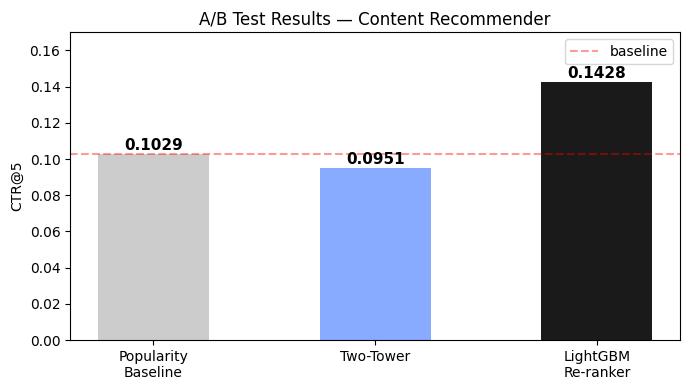

✅ Chart saved!


In [22]:
import matplotlib.pyplot as plt
import os

os.makedirs('/kaggle/working/results', exist_ok=True)

models = ['Popularity\nBaseline', 'Two-Tower', 'LightGBM\nRe-ranker']
ctrs   = [0.1029, 0.0951, 0.1428]
colors = ['#ccc', '#88aaff', '#1a1a1a']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, ctrs, color=colors, width=0.5)
ax.set_ylabel('CTR@5')
ax.set_title('A/B Test Results — Content Recommender')

for bar, val in zip(bars, ctrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 0.17)
ax.axhline(y=0.1029, color='red', linestyle='--', alpha=0.4, label='baseline')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/results/ab_test_results.png', dpi=150)
plt.show()
print("✅ Chart saved!")

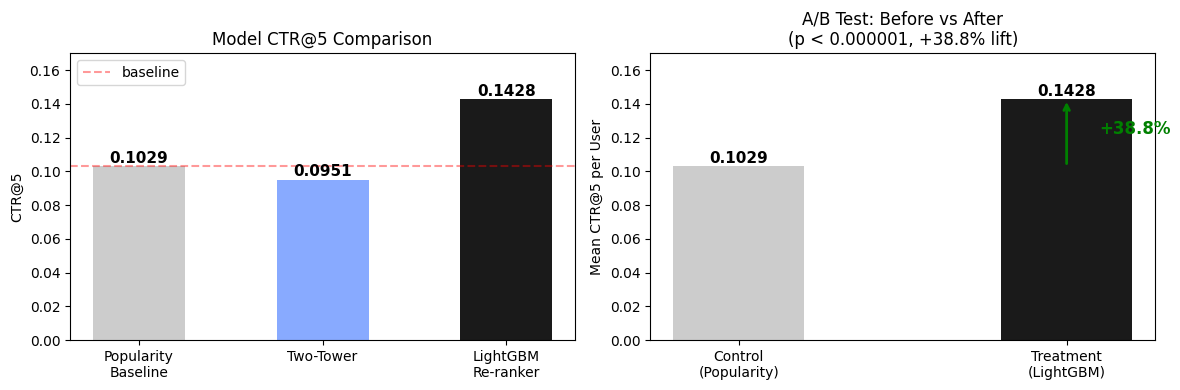

✅ Both charts saved!


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Chart 1: CTR comparison ───────────────────────────────
models = ['Popularity\nBaseline', 'Two-Tower', 'LightGBM\nRe-ranker']
ctrs   = [0.1029, 0.0951, 0.1428]
colors = ['#ccc', '#88aaff', '#1a1a1a']

bars = axes[0].bar(models, ctrs, color=colors, width=0.5)
axes[0].set_ylabel('CTR@5')
axes[0].set_title('Model CTR@5 Comparison')
axes[0].set_ylim(0, 0.17)
axes[0].axhline(y=0.1029, color='red', linestyle='--', alpha=0.4, label='baseline')
for bar, val in zip(bars, ctrs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].legend()

# ── Chart 2: A/B test before vs after ────────────────────
groups  = ['Control\n(Popularity)', 'Treatment\n(LightGBM)']
ab_ctrs = [0.1029, 0.1428]
colors2 = ['#ccc', '#1a1a1a']

bars2 = axes[1].bar(groups, ab_ctrs, color=colors2, width=0.4)
axes[1].set_ylabel('Mean CTR@5 per User')
axes[1].set_title('A/B Test: Before vs After\n(p < 0.000001, +38.8% lift)')
axes[1].set_ylim(0, 0.17)

for bar, val in zip(bars2, ab_ctrs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Annotation arrow
axes[1].annotate('', xy=(1, 0.1428), xytext=(1, 0.1029),
                 arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[1].text(1.1, 0.122, '+38.8%', color='green', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/results/performance_charts.png', dpi=150)
plt.show()
print("✅ Both charts saved!")

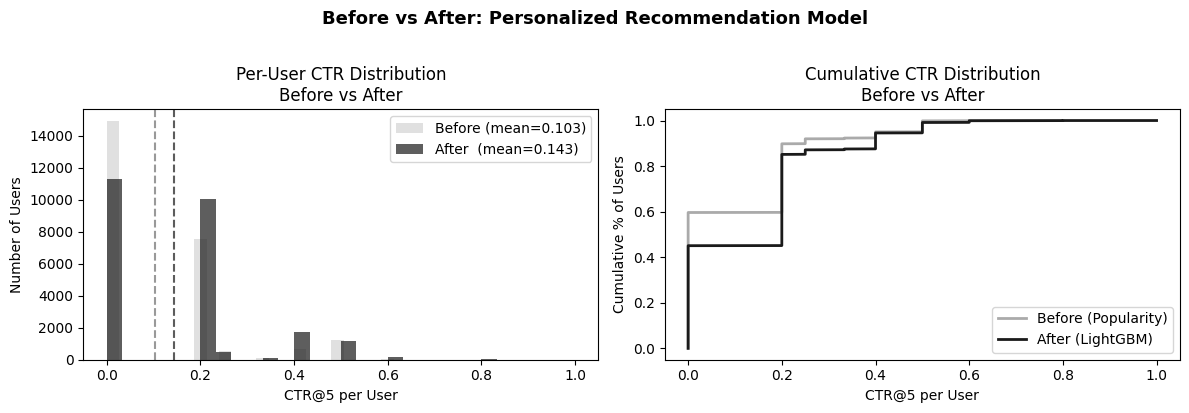

✅ Before/after chart saved!


In [24]:
# Get per-user CTR for control and treatment from the A/B test
control_users   = set(np.random.RandomState(42).choice(df['user_id'].unique(), len(df['user_id'].unique())//2, replace=False))
treatment_users = set(df['user_id'].unique()) - control_users

control   = df[df['user_id'].isin(control_users)]
treatment = df[df['user_id'].isin(treatment_users)]

def user_level_ctr(logs, score_col, k=5):
    logs = logs.copy()
    logs['rank'] = logs.groupby('user_id')[score_col].rank(ascending=False, method='first')
    top_k = logs[logs['rank'] <= k]
    return top_k.groupby('user_id')['clicked'].mean()

control_ctrs   = user_level_ctr(control,   'pop_score')
treatment_ctrs = user_level_ctr(treatment, 'lgbm_score')

# ── Plot distribution before vs after ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution overlay
axes[0].hist(control_ctrs,   bins=30, alpha=0.6, color='#ccc',    label=f'Before (mean={control_ctrs.mean():.3f})')
axes[0].hist(treatment_ctrs, bins=30, alpha=0.7, color='#1a1a1a', label=f'After  (mean={treatment_ctrs.mean():.3f})')
axes[0].set_xlabel('CTR@5 per User')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Per-User CTR Distribution\nBefore vs After')
axes[0].legend()
axes[0].axvline(control_ctrs.mean(),   color='gray',    linestyle='--', alpha=0.8)
axes[0].axvline(treatment_ctrs.mean(), color='#333',    linestyle='--', alpha=0.8)

# Cumulative distribution
import numpy as np
control_sorted   = np.sort(control_ctrs)
treatment_sorted = np.sort(treatment_ctrs)
axes[1].plot(control_sorted,   np.linspace(0,1,len(control_sorted)),   color='#aaa',    label='Before (Popularity)', linewidth=2)
axes[1].plot(treatment_sorted, np.linspace(0,1,len(treatment_sorted)), color='#1a1a1a', label='After (LightGBM)',    linewidth=2)
axes[1].set_xlabel('CTR@5 per User')
axes[1].set_ylabel('Cumulative % of Users')
axes[1].set_title('Cumulative CTR Distribution\nBefore vs After')
axes[1].legend()

plt.suptitle('Before vs After: Personalized Recommendation Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/results/before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Before/after chart saved!")